# Causal RL, hands-on: three levels of the Pearl hierarchy

**An applied-math walkthrough of `causalrl`.**

The thesis of causal reinforcement learning is that an agent equipped with a *causal model*
makes decisions a correlation-only agent provably cannot. We make that concrete with three
self-contained bandit problems, one per rung of the **Pearl Causal Hierarchy**:

| Demo | Rung | Question the agent must answer | Causal agent | Naive agent |
|------|------|-------------------------------|:------------:|:-----------:|
| **1. MABUC** | $L_1\!\to\!L_2$ | *Which arm, when the $do()$-means are equal?* | **0.76** | 0.50 |
| **2. POMIS** | $L_2$ | *Where, among $2^n$ intervention sets, is it worth intervening?* | **1.00** | 0.50 |
| **3. Counterfactual policy** | $L_3$ | *Given my intent, what is $\mathbb{E}[Y_{do(a)}\mid\text{intent}]$?* | **0.80** | 0.37 |

The recurring punchline: in every demo the **interventional** signal alone is uninformative
(all arms look identical under $do$), yet the *observational* or *counterfactual* signal breaks
the tie. Everything here is tabular and runs in seconds.

> Reference spine: Bareinboim's [9-task taxonomy of causal RL](https://crl.causalai.net/);
> Pearl, *Causality*; Bareinboim, Forney & Pearl, *Bandits with Unobserved Confounders* (NeurIPS 2015);
> Lee & Bareinboim, *Structural Causal Bandits* (NeurIPS 2018).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

BLUE, RED, GREY = "#1f77b4", "#d62728", "#999999"
rng = np.random.default_rng(0)


def running_mean(x):
    x = np.asarray(x, float)
    return np.cumsum(x) / (np.arange(len(x)) + 1)


def run_bandit(agent, env, n=8000, seed=1):
    """One pull per episode; reset draws a fresh confounder. Returns the reward sequence."""
    obs, _ = env.reset(seed=seed)
    rewards = []
    for _ in range(n):
        a = agent.act(obs)
        _, r, _, _, _ = env.step(a)
        agent.update(obs, a, r)
        obs, _ = env.reset()
        rewards.append(r)
    return np.asarray(rewards, float)

## Demo 1 — MABUC: the founding paradox ($L_1$ vs $L_2$)

The **Multi-Armed Bandit with Unobserved Confounders.** A latent state (mood/context)
$U=(D,B)$ drives *both* the agent's gut *intuition* $I=D\oplus B$ and which arm is lucky.
The structural model is `U → I → X → Y`, `U → Y`.

The trap, stated for a math audience: the two arms are **interventionally indistinguishable**,
$$\mathbb{E}[Y\mid do(X{=}0)] \;=\; \mathbb{E}[Y\mid do(X{=}1)] \;=\; \tfrac12 .$$
An agent that reasons only at $L_2$ (the $do$-level) is provably stuck at 0.5 — $do(X{=}a)$ severs
the edge $U\to X$, averaging the confounder away. But the **observational** quantity
$\mathbb{E}[Y\mid X{=}a, I{=}i]$ is *not* flat: the agent's own intuition $I$ is a measurable
proxy for $U$. `CausalThompsonSampling` keeps one Beta posterior per $(I, a)$ cell and recovers
the lucky arm; `NaiveThompsonSampling` marginalizes $I$ away and cannot.

In [2]:
from causalrl.envs.suite.mabuc import build_mabuc_scm

scm = build_mabuc_scm()
do0 = scm.do({"X": 0.0}).see(20000, seed=0)["Y"].mean().item()
do1 = scm.do({"X": 1.0}).see(20000, seed=1)["Y"].mean().item()
print(f"E[Y | do(X=0)] = {do0:.3f}")
print(f"E[Y | do(X=1)] = {do1:.3f}   <- identical: no do()-only agent can choose")

E[Y | do(X=0)] = 0.500
E[Y | do(X=1)] = 0.501   <- identical: no do()-only agent can choose


In [3]:
from causalrl.agents.bandits import CausalThompsonSampling, NaiveThompsonSampling
from causalrl.envs.suite.mabuc import MABUCEnv

causal = run_bandit(CausalThompsonSampling(n_arms=2, n_contexts=2, seed=0), MABUCEnv(seed=1))
naive = run_bandit(NaiveThompsonSampling(n_arms=2, seed=0), MABUCEnv(seed=1))
print(f"Causal TS avg reward: {causal.mean():.3f}")
print(f"Naive  TS avg reward: {naive.mean():.3f}")

Causal TS avg reward: 0.756
Naive  TS avg reward: 0.504


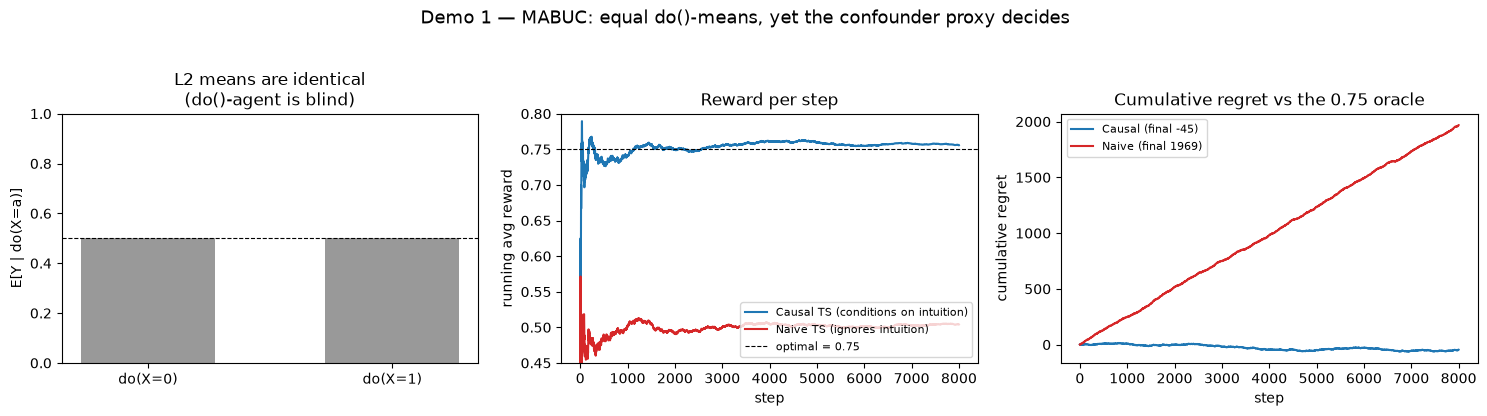

In [4]:
opt = 0.75
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(15, 4.2))

ax0.bar(["do(X=0)", "do(X=1)"], [do0, do1], color=GREY, width=0.55)
ax0.axhline(0.5, ls="--", c="k", lw=0.8); ax0.set_ylim(0, 1)
ax0.set_ylabel("E[Y | do(X=a)]")
ax0.set_title("L2 means are identical\n(do()-agent is blind)")

ax1.plot(running_mean(causal), color=BLUE, label="Causal TS (conditions on intuition)")
ax1.plot(running_mean(naive), color=RED, label="Naive TS (ignores intuition)")
ax1.axhline(opt, ls="--", c="k", lw=0.8, label="optimal = 0.75")
ax1.set_ylim(0.45, 0.8); ax1.set_xlabel("step"); ax1.set_ylabel("running avg reward")
ax1.set_title("Reward per step"); ax1.legend(loc="lower right", fontsize=8)

cr_c, cr_n = np.cumsum(opt - causal), np.cumsum(opt - naive)
ax2.plot(cr_c, color=BLUE, label=f"Causal (final {cr_c[-1]:.0f})")
ax2.plot(cr_n, color=RED, label=f"Naive (final {cr_n[-1]:.0f})")
ax2.set_xlabel("step"); ax2.set_ylabel("cumulative regret")
ax2.set_title("Cumulative regret vs the 0.75 oracle"); ax2.legend(loc="upper left", fontsize=8)

fig.suptitle("Demo 1 — MABUC: equal do()-means, yet the confounder proxy decides", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.95)); plt.show()

## Demo 2 — POMIS: *where* to intervene ($L_2$, combinatorial)

Now the lever is not "which value" but "which **variables** to set." With $n$ manipulable
variables there are $2^n$ candidate intervention sets — exponential. **POMIS**
(*Possibly-Optimal Minimal Intervention Sets*, Lee & Bareinboim 2018) uses the graph topology to
prove that all but a handful can be discarded *without ever pulling them*.

We use the confounded chain $X_1\to X_2\to X_3\to Y$ with a back-door $X_1\leftrightarrow Y$.
Enumerating arms (each variable $\in\{\text{idle},0,1\}$) gives **27 candidate arms**, but
$$\textsf{POMIS}(\,\mathcal{G}, Y\,) = \{\,\varnothing,\ \{X_3\}\,\}.$$
Two interpretations a math audience will appreciate: (i) intervening upstream ($X_1$ or $X_2$)
*destroys* the very $X_3\to Y$ effect you want, so it cannot be optimal; (ii) the empty set
$\varnothing$ — pure **observation** — is itself a candidate, and here it *wins* (the MABUC
effect, lifted onto a chain). The POMIS agent searches 2 arms; brute force flails over 27.

In [5]:
from causalrl import pomis
from causalrl.envs.suite.scbandit import make_confounded_chain_env

env = make_confounded_chain_env(seed=1)
print("candidate arms (brute force):", env.action_space.n)
print("POMIS(graph, 'Y'):", pomis(env.graph, "Y"))
print("optimal value:", round(env.optimal_value, 3))

candidate arms (brute force): 27
POMIS(graph, 'Y'): [frozenset(), frozenset({'X3'})]
optimal value: 1.0


In [6]:
from causalrl.agents.scbandit import (
    BruteForceInterventionTS,
    FixedSetThompsonSampling,
    POMISThompsonSampling,
)


def run_sc(agent, steps=8000, seed=1):
    obs, _ = env.reset(seed=seed)
    rewards = []
    for _ in range(steps):
        a = agent.act(obs)
        nobs, r, _, _, _ = env.step(a)
        agent.update(obs, a, r)
        rewards.append(r)
        obs = nobs
    return np.asarray(rewards, float)


pomis_r = run_sc(POMISThompsonSampling(env.graph, env.reward, env.arms, seed=0,
                                       manipulable=env.manipulable))
brute_r = run_sc(BruteForceInterventionTS(env.arms, seed=0), seed=2)
naive_r = run_sc(FixedSetThompsonSampling(env.arms, {"X3"}, seed=0), seed=3)
print(f"POMIS {pomis_r[-2000:].mean():.3f} | brute {brute_r[-2000:].mean():.3f} | "
      f"naive do(X3) {naive_r[-2000:].mean():.3f}")

POMIS 1.000 | brute 1.000 | naive do(X3) 0.504


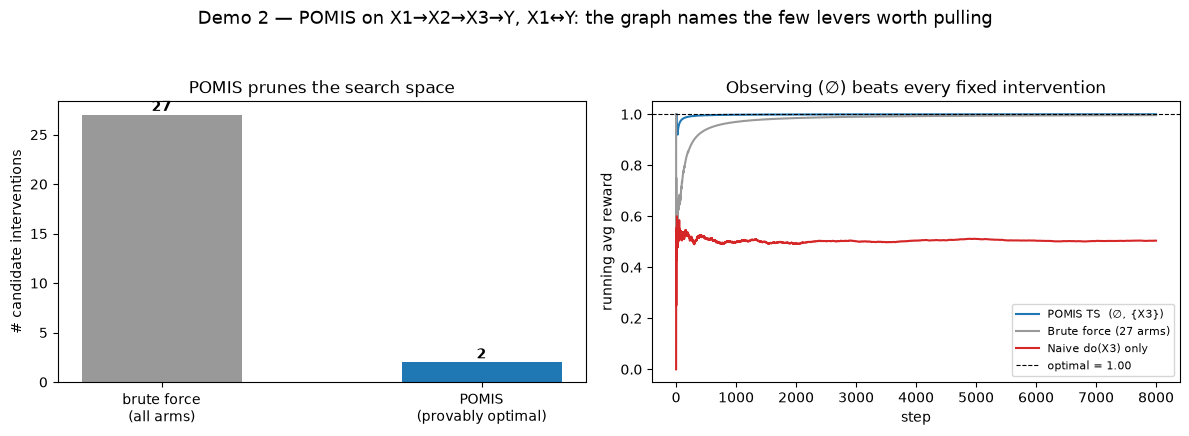

In [7]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4.4))
n_arms, n_pomis = env.action_space.n, len(pomis(env.graph, "Y"))

ax0.bar(["brute force\n(all arms)", "POMIS\n(provably optimal)"], [n_arms, n_pomis],
        color=[GREY, BLUE], width=0.5)
ax0.set_ylabel("# candidate interventions"); ax0.set_title("POMIS prunes the search space")
for i, v in enumerate([n_arms, n_pomis]):
    ax0.text(i, v + 0.4, str(v), ha="center", fontweight="bold")

ax1.plot(running_mean(pomis_r), color=BLUE, label="POMIS TS  (∅, {X3})")
ax1.plot(running_mean(brute_r), color=GREY, label="Brute force (27 arms)")
ax1.plot(running_mean(naive_r), color=RED, label="Naive do(X3) only")
ax1.axhline(env.optimal_value, ls="--", c="k", lw=0.8, label=f"optimal = {env.optimal_value:.2f}")
ax1.set_xlabel("step"); ax1.set_ylabel("running avg reward")
ax1.set_title("Observing (∅) beats every fixed intervention"); ax1.legend(loc="lower right", fontsize=8)

fig.suptitle("Demo 2 — POMIS on X1→X2→X3→Y, X1↔Y: the graph names the few levers worth pulling",
             fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.93)); plt.show()

## Demo 3 — Counterfactual policy: act on $\mathbb{E}[Y_{do(a)}\mid \text{intent}]$ ($L_3$)

Finally, the top rung. A 3-arm bandit with hidden $U\in\{0,1,2\}$: the lucky arm *is* $U$
(reward 0.8 if played arm $=U$, else 0.15), and the agent's intent satisfies $I=U$. The
behaviour policy plays $X=I$, so it is *implicitly optimal* — the observational mean is 0.8 —
yet **every fixed intervention collapses to chance**:
$$\mathbb{E}[Y\mid do(X{=}a)] = \tfrac13(0.8) + \tfrac23(0.15) \approx 0.37 \quad\forall a.$$
The fix is a genuinely **counterfactual** ($L_3$) query — Bareinboim, Forney & Pearl's *Regret
Decision Criterion*: "given that I am inclined toward $i$, what is the best action?"
$$\pi^\star(i) = \arg\max_a\ \mathbb{E}\big[\,Y_{do(X=a)} \,\big|\, I = i\,\big].$$
`CounterfactualOptimalPolicy` precomputes this table from the SCM. Its diagonal structure (below)
says: **trust your intuition** — but only because the counterfactual confirms it.

In [8]:
from causalrl import CounterfactualOptimalPolicy
from causalrl.envs.suite.counterfactual_bandit import (
    build_counterfactual_scm,
    make_counterfactual_bandit_env,
)

scm3 = build_counterfactual_scm()
cf_agent = CounterfactualOptimalPolicy(
    scm3, outcome="Y", action_node="X", intent_node="I",
    arms=[0, 1, 2], intents=[0, 1, 2], seed=0,
)
table = cf_agent.decision_table           # {intent: {arm: E[Y_do(arm) | intent]}}
M = np.array([[table[i][a] for a in (0, 1, 2)] for i in (0, 1, 2)])
print("E[Y | do(X=a)] marginal over intents:", M.mean(axis=0).round(3), " (all ~0.37)")

E[Y | do(X=a)] marginal over intents: [0.368 0.37  0.372]  (all ~0.37)


In [9]:
cf = run_bandit(cf_agent, make_counterfactual_bandit_env(seed=1))
naive3 = run_bandit(NaiveThompsonSampling(n_arms=3, seed=0), make_counterfactual_bandit_env(seed=1))
print(f"Counterfactual policy avg: {cf.mean():.3f}")
print(f"Naive TS (best fixed arm): {naive3.mean():.3f}")

Counterfactual policy avg: 0.797
Naive TS (best fixed arm): 0.360


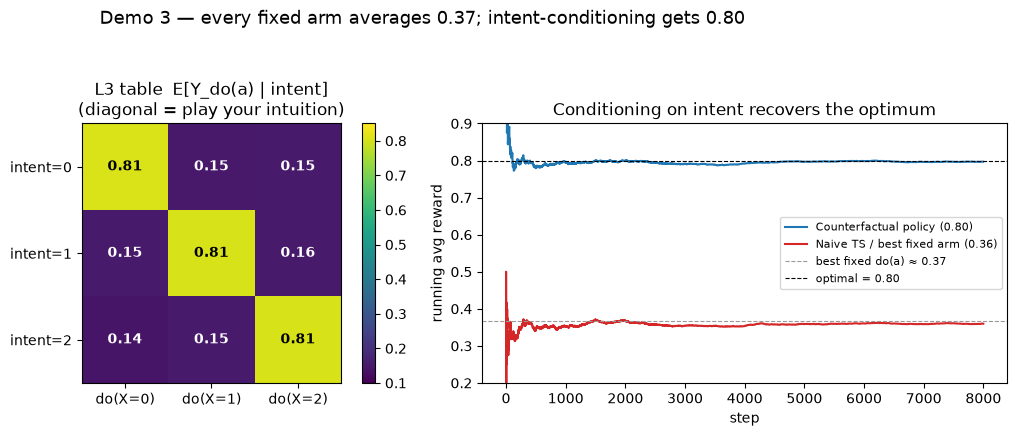

In [10]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4.4))

im = ax0.imshow(M, cmap="viridis", vmin=0.1, vmax=0.85)
ax0.set_xticks([0, 1, 2], ["do(X=0)", "do(X=1)", "do(X=2)"])
ax0.set_yticks([0, 1, 2], ["intent=0", "intent=1", "intent=2"])
for i in range(3):
    for j in range(3):
        ax0.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center",
                 color="white" if M[i, j] < 0.5 else "black", fontweight="bold")
ax0.set_title("L3 table  E[Y_do(a) | intent]\n(diagonal = play your intuition)")
fig.colorbar(im, ax=ax0, fraction=0.046, pad=0.04)

ax1.plot(running_mean(cf), color=BLUE, label=f"Counterfactual policy ({cf.mean():.2f})")
ax1.plot(running_mean(naive3), color=RED, label=f"Naive TS / best fixed arm ({naive3.mean():.2f})")
ax1.axhline(0.367, ls="--", c=GREY, lw=0.8, label="best fixed do(a) ≈ 0.37")
ax1.axhline(0.8, ls="--", c="k", lw=0.8, label="optimal = 0.80")
ax1.set_ylim(0.2, 0.9); ax1.set_xlabel("step"); ax1.set_ylabel("running avg reward")
ax1.set_title("Conditioning on intent recovers the optimum"); ax1.legend(loc="center right", fontsize=8)

fig.suptitle("Demo 3 — every fixed arm averages 0.37; intent-conditioning gets 0.80", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.93)); plt.show()

## Takeaways

1. **A causal model buys decisions correlation cannot.** In all three demos the $L_2$
   ($do$) signal is degenerate — every arm looks equal — and the win comes from a strictly
   higher rung: observing a confounder proxy ($L_1$ conditioning, Demos 1–2) or an explicit
   counterfactual query ($L_3$, Demo 3).
2. **The graph is an oracle for "where to act."** POMIS turns an exponential intervention
   search into a 2-element set *before any data is collected* — pure structure.
3. **"Trust your intuition" becomes a theorem.** The $L_3$ decision table makes the
   confounder-as-signal argument precise and computable: $\arg\max_a \mathbb{E}[Y_{do(a)}\mid I]$.

### Where to go next in `causalrl`
- **Task 1 — offline→online** under confounding via Manski bounds (`UCDTR`, `DOVI`): see
  `examples/offline_to_online.ipynb`.
- **Identification layer**: `identify_effect` (complete Shpitser–Pearl ID), `manski_bounds`,
  `certify_decision` — all *conservative by design* (they return `None`/raise outside their
  supported class rather than guess).
- The full **Tour by Task** covers transportability, causal discovery (PC/FCI), imitation,
  curriculum, reward shaping and causal games.

*All figures are reproducible offline via* `uv run python examples/presentation/_build_figures.py`.